# The Vol-Managed Portfolio — a quantitative teardown 🔬
### Newey-West alpha of managed-on-unmanaged · appraisal ratio · a 200-seed shuffled-RV placebo · asset & cap robustness · borrow-spread cost sweep · crash-window drawdowns · a three-world synthetic control

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Dodges_crashes%3F: Mixed](https://img.shields.io/badge/Dodges_crashes%3F-Mixed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Moreira & Muir (2017, JF) is a heavyweight claim with a heavyweight rebuttal literature (Cederburg et al. 2020; Barroso & Detzel 2021) — so the job is an honest middle: past-only normaliser, one clean lag, excess-vs-excess, HAC inference, and costs that include the *borrow spread* the levered half actually pays.

> ⚠️ **Data note.** yfinance total-return closes, SPY 1993-02→2026-06 headline (QQQ/EFA/IWM robustness), rf = ^IRX/100/252 on both legs (cancels in the race). No survivorship (single continuously-listed index ETFs). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `11ef90f96ced`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from vol_managed_portfolio import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    DF = data.complete_months(data.daily_frames("SPY"))
    TBL = st.monthly_table(DF)
    W = st.weights_from_rv(TBL["rv"].values)
else:
    DF = TBL = W = None
print("real cache present:", HAVE_REAL,
      "| complete months:", (0 if TBL is None else len(TBL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1993-02-01', 'end': '2026-06-30', 'n_days': 8410, 'n_months': 401, 'n_strat': 388, 'avg_w': 1.12, 'share_capped': 48.7, 'turnover': 0.21, 'cap': 1.5, 'sharpe_man': 0.717, 'sharpe_bh': 0.606, 'alpha': 2.87, 't_alpha': 2.0, 'beta': 0.844, 'appraisal': 0.383, 'resid_vol': 7.5, 'lags': 5, 'placebo_mean_t': -0.06, 'placebo_sd_t': 1.12, 'placebo_mean_alpha': 0.01, 'p_placebo': 0.03, 'n_placebo': 200, 'costs': [('gross', 0, 0, 2.87, 2.0, 0.717), ('5 bps + 1% borrow', 5, 1, 2.46, 1.72, 0.69), ('10 bps + 2% borrow', 10, 2, 2.06, 1.44, 0.662)], 'crashes': [('GFC 2008-09', -31.0, -50.8), ('COVID 2020', -18.2, -19.4), ('2022 bear', -15.8, -20.2), ('full sample', -39.4, -50.8)], 'assets': [('SPY', 388, 2.87, 2.0, 0.717, 0.606), ('QQQ', 315, 5.49, 2.61, 0.556, 0.383), ('EFA', 285, 1.92, 0.84, 0.507, 0.456), ('IWM', 300, 1.71, 0.72, 0.47, 0.437)], 'caps': [(1.0, 1.44, 1.44, 0.676), (1.5, 2.87, 2.0, 0.717), (2.0, 3.99, 2.17, 0.728)], 'syn': [('NULL (mean ~ variance)', 0, -0.08, 1.24, -0.1, 0), ('flat mean', 1, 1.08, 1.1, 2.44, 25), ('PLANTED leverage effect', 2, 2.09, 0.98, 5.01, 60)], 'fingerprint': '11ef90f96ced'}


real cache present: True | complete months: 401


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `MIXED` | SPY alpha **+2.87%/yr**, NW **t = 2.00** (at the wire); QQQ **t = 2.61**; placebo **p = 0.030** — but EFA **t = 0.84**, IWM **t = 0.72**, cap-1.0 variant t = 1.44. Real on US mega-caps, unsupported elsewhere. |
| **Tradability** | `FRAGILE` | Net of 5 bps + 1%/yr borrow spread: alpha **+2.46%/yr, t = 1.72** — decertified. Sharpe still 0.69 vs 0.61. |
| **Dodges crashes?** | `MIXED` | GFC **−31.0% vs −50.8%** (dodged); COVID 2020 **−18.2% vs −19.4%** (no dodge — entered at the 1.5× cap); 2022 **−15.8% vs −20.2%**. |

> 💡 In plain words: the thermostat genuinely improves SPY, the proof holds by a fingernail gross and lets go once the margin loan is priced, and the crash-dodging reputation is only half-earned.

## 1 · The claim, steelmanned

Let $RV_m=\sum_{d\in m} r_d^2$ be month-$m$ realized variance and $c_m$ the expanding mean of $RV$ through $m$. The rule holds, for month $m{+}1$,

$$w_{m+1}=\min\!\big(1.5,\; c_m/RV_m\big),\qquad r^{mgd}_{m+1}=w_{m+1}\,(r_{m+1}-rf_{m+1}).$$

Moreira-Muir's test is the time-series regression
$$r^{mgd}_t=\alpha+\beta\,r^{bh}_t+\varepsilon_t$$
with HAC errors: $\alpha>0$ means the managed portfolio expands the mean-variance frontier of the unmanaged one.

- **H₁ (alpha).** $\alpha > 0$ with NW $t \ge 2$ on the real tape.
- **H₂ (deployability).** $\alpha$ survives turnover costs *and* the retail borrow spread on $\max(w-1,0)$.
- **H₃ (crash dodging).** Managed drawdowns are materially shallower in 2008 / 2020 / 2022.

We find **H₁ split** (SPY 2.00, QQQ 2.61 — EFA/IWM fail), **H₂ rejected** (t = 1.72 net), **H₃ half-confirmed** (slow crashes yes, sudden no).

## 2 · So what? — what rides on each answer

The alpha regression is the right null: a Sharpe comparison alone can flatter any strategy that just holds less beta. $\alpha$ asks whether the managed return is explainable by a *constant* exposure to the same asset — if not, the timing itself added value. Honesty requirements on top: **(a)** the paper's variance-matching constant $c$ uses the full sample — ours is expanding, past-only; **(b)** leverage financing must be at T-bills *plus a spread* for anyone who isn't a prime-brokered fund; **(c)** the placebo must rebuild the entire rule per shuffle, not just scramble returns.

## 3 · How we'd know — the protocol

- **Tape.** SPY 1993-02-01→2026-06-30 (401 complete months; 388 strategy months after a 12-month RV burn-in). Partial months dropped; as-of 2026-06-30.
- **Signal.** $RV_m$ = sum of squared daily total returns of month $m$; weight for $m{+}1$ = $\min(1.5, c_m/RV_m)$ — **one** execution lag, set at the month-$m$ close.
- **Inference.** NW (Bartlett) HAC $t$ on $\alpha$, rule-of-thumb lags (5 here); appraisal ratio $\alpha/\sigma_\varepsilon$; excess-vs-excess Sharpe race with HAC mean tests.
- **Placebo.** 200 seeds: permute the monthly RV series, rebuild weights + regression per seed; $p=\Pr[\alpha_{shuf}\ge\alpha_{obs}]$.
- **Costs.** One-way bps × |Δw| × NAV + borrow spread × max(w−1,0)/12.
- **Robustness.** QQQ / EFA / IWM; cap ∈ {1.0, 1.5, 2.0}.
- **Control.** Three synthetic vol-clustered worlds (20 seeds each): risk-priced null must earn nothing; the planted leverage-effect world must light up.

## 4 · The teardown

### 4a · The alpha and its placebo

The observed Moreira-Muir alpha against the distribution of alphas from 200 shuffled-RV rebuilds (the timing information destroyed, everything else intact).

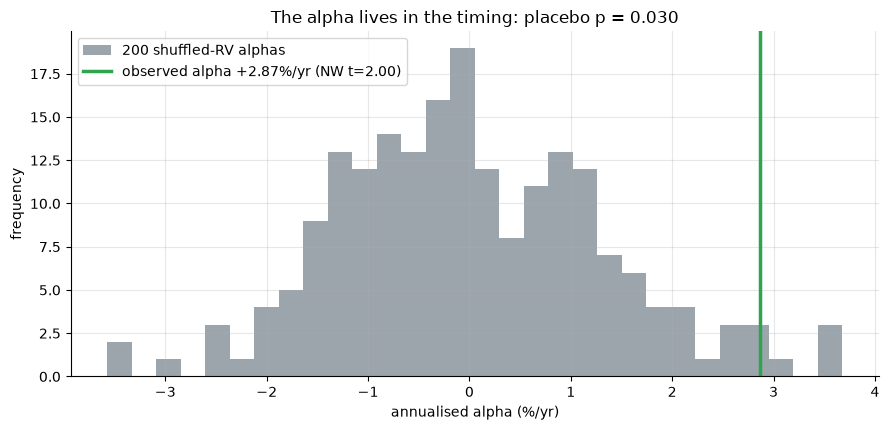

observed +2.87%/yr (t=+2.004)  shuffled mean +0.01%/yr  p=0.030


In [2]:
if HAVE_REAL:
    g = st.race_summary(TBL['exc'].values, TBL['rv'].values)
    obs_a, obs_t = g['reg_alpha_ann_pct'], g['reg_t_alpha']
    rng_alphas = []
    for s in range(200):
        rng = np.random.default_rng(591 + s)
        r = st.race_summary(TBL['exc'].values, rng.permutation(TBL['rv'].values))
        rng_alphas.append(r['reg_alpha_ann_pct'])
    draws = np.array(rng_alphas); pval = float((draws >= obs_a).mean())
else:
    obs_a, obs_t, pval = R['alpha'], R['t_alpha'], R['p_placebo']
    draws = np.random.default_rng(591).normal(0, 1.5, 200)
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.hist(draws, bins=30, color=GREY, alpha=.85, label='200 shuffled-RV alphas')
ax.axvline(obs_a, c=GREEN, lw=2.5, label=f'observed alpha {obs_a:+.2f}%/yr (NW t={obs_t:.2f})')
ax.set_xlabel('annualised alpha (%/yr)'); ax.set_ylabel('frequency')
ax.set_title(f'The alpha lives in the timing: placebo p = {pval:.3f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obs_a:+.2f}%/yr (t={obs_t:+.3f})  shuffled mean {draws.mean():+.2f}%/yr  p={pval:.3f}')

> 💡 In plain words: a random vol signal with the exact same *distribution* earns **~0%/yr** — the real signal earns **+2.87%/yr** and only **3%** of shuffles beat it. The alpha is the *alignment* of calm-follows-calm, not the weight distribution. But note the certification is at the wire: NW **t = 2.00** exactly at the desk bar, beta 0.84, appraisal 0.38.

### 4b · Robustness — where the signal lives (assets and the cap)

Same rule, four ETFs; then the leverage cap swept on SPY.

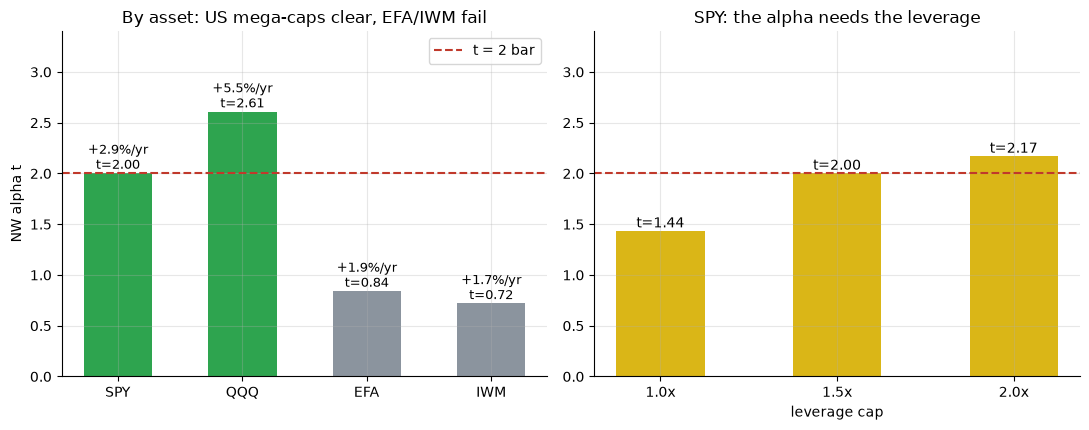

assets: [('SPY', 2.87, 2.0), ('QQQ', 5.49, 2.61), ('EFA', 1.92, 0.84), ('IWM', 1.71, 0.72)]
caps  : [(1.0, 1.44), (1.5, 2.0), (2.0, 2.17)]


In [3]:
if HAVE_REAL:
    rows = []
    for tk in ('SPY','QQQ','EFA','IWM'):
        d2 = data.complete_months(data.daily_frames(tk)); t2 = st.monthly_table(d2)
        r2 = st.race_summary(t2['exc'].values, t2['rv'].values)
        rows.append((tk, r2['reg_alpha_ann_pct'], r2['reg_t_alpha']))
    caps = [(c, st.race_summary(TBL['exc'].values, TBL['rv'].values, cap=c)['reg_t_alpha'])
            for c in (1.0, 1.5, 2.0)]
else:
    rows = [(a[0], a[2], a[3]) for a in R['assets']]
    caps = [(c[0], c[2]) for c in R['caps']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.4))
cols = [GREEN if r[2] >= 2 else GREY for r in rows]
a1.bar([r[0] for r in rows], [r[2] for r in rows], color=cols, width=.55)
a1.axhline(2, ls='--', c=RED, label='t = 2 bar')
for i, r in enumerate(rows): a1.annotate(f'{r[1]:+.1f}%/yr\nt={r[2]:.2f}', (i, r[2]), ha='center', va='bottom', fontsize=9)
a1.set_ylabel('NW alpha t'); a1.set_ylim(0, 3.4); a1.set_title('By asset: US mega-caps clear, EFA/IWM fail'); a1.legend()
a2.bar([f'{c[0]:.1f}x' for c in caps], [c[1] for c in caps], color=AMBER, width=.5)
a2.axhline(2, ls='--', c=RED)
for i, c in enumerate(caps): a2.annotate(f't={c[1]:.2f}', (i, c[1]), ha='center', va='bottom')
a2.set_xlabel('leverage cap'); a2.set_ylim(0, 3.4); a2.set_title('SPY: the alpha needs the leverage')
plt.tight_layout(); plt.show()
print('assets:', [(r[0], round(r[1],2), round(r[2],2)) for r in rows])
print('caps  :', [(c[0], round(c[1],2)) for c in caps])

> 💡 In plain words: the effect certifies exactly where volatility clustering is strongest and cleanest — **SPY (t = 2.00) and QQQ (t = 2.61)** — and evaporates statistically on EFA (t = 0.84) and IWM (t = 0.72), though every point estimate is positive. And the long-only version (cap 1.0×) is only half the story: t = 1.44. This is a **split** verdict, stamped MIXED, not a universal law — consistent with Cederburg et al. (2020).

### 4c · Costs — the borrow spread is the killer, not the turnover

Average |Δw| is only 0.21/month, so commissions are noise. The levered half of the calendar is the real bill: retail margin financing runs 1–2%/yr above T-bills (futures get closer to flat, with roll and basis instead).

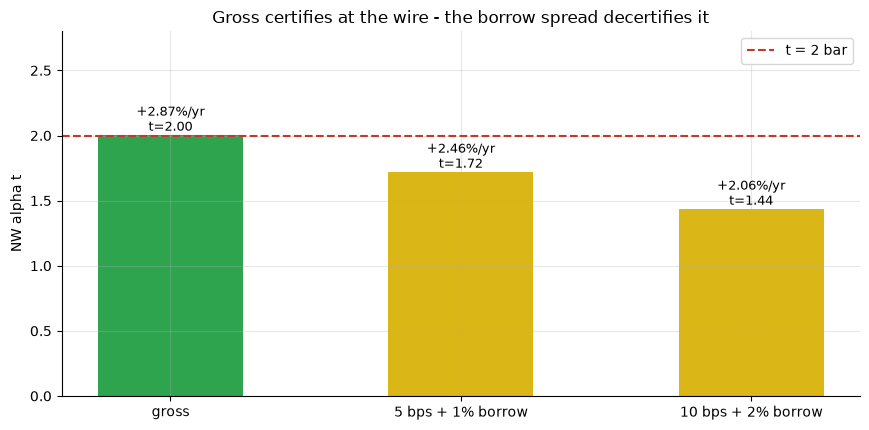

[('gross', 2.87, 2.0, np.float64(0.717)), ('5 bps + 1% borrow', 2.46, 1.72, np.float64(0.69)), ('10 bps + 2% borrow', 2.06, 1.44, np.float64(0.662))]


In [4]:
if HAVE_REAL:
    scen = [('gross', 0.0, 0.0), ('5 bps + 1% borrow', 5.0, 0.01), ('10 bps + 2% borrow', 10.0, 0.02)]
    res = [(lab,) + tuple(st.race_summary(TBL['exc'].values, TBL['rv'].values, cost_bps=cb,
            borrow_spread_ann=sp)[k] for k in ('reg_alpha_ann_pct','reg_t_alpha','sharpe_managed'))
           for lab, cb, sp in scen]
else:
    res = [(c[0], c[3], c[4], c[5]) for c in R['costs']]
labs = [r[0] for r in res]; ts = [r[2] for r in res]
fig, ax = plt.subplots(figsize=(8.8, 4.4))
ax.bar(labs, ts, color=[GREEN, AMBER, AMBER], width=.5)
ax.axhline(2, ls='--', c=RED, label='t = 2 bar')
for i, r in enumerate(res): ax.annotate(f'{r[1]:+.2f}%/yr\nt={r[2]:.2f}', (i, r[2]), ha='center', va='bottom', fontsize=9)
ax.set_ylabel('NW alpha t'); ax.set_ylim(0, 2.8)
ax.set_title('Gross certifies at the wire - the borrow spread decertifies it'); ax.legend()
plt.tight_layout(); plt.show()
print([(r[0], round(r[1],2), round(r[2],2), round(r[3],3)) for r in res])

> 💡 In plain words: at 5 bps + 1% borrow the point estimate is still **+2.46%/yr** and the net Sharpe (0.69) still beats buy-and-hold (0.61) — but the proof is gone (t = 1.72). You may well still be better off; you can no longer *demonstrate* it. That's FRAGILE.

### 4d · The third axis — which crashes does it dodge?

Max drawdown of monthly total-return NAVs inside each crash window.

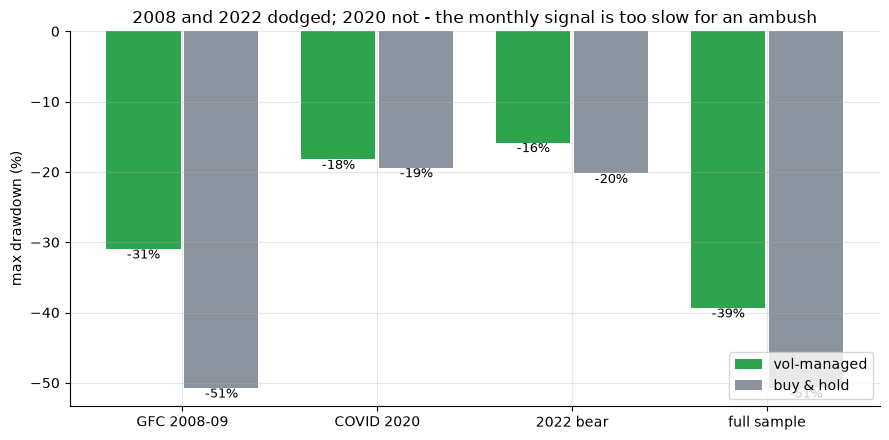

{'GFC 2008-09': (-31.0, -50.8), 'COVID 2020': (-18.2, -19.4), '2022 bear': (-15.8, -20.2), 'full sample': (-39.4, -50.8)}


In [5]:
if HAVE_REAL:
    ct = st.crash_table(TBL)
    rows = [(k, v['managed']*100, v['bh']*100) for k, v in ct.items()]
else:
    rows = list(R['crashes'])
labs = [r[0] for r in rows]; man = [r[1] for r in rows]; bh = [r[2] for r in rows]
x = np.arange(len(labs))
fig, ax = plt.subplots(figsize=(9.0, 4.5))
ax.bar(x-.2, man, .38, color=GREEN, label='vol-managed')
ax.bar(x+.2, bh, .38, color=GREY, label='buy & hold')
for i,(m,b) in enumerate(zip(man,bh)):
    ax.annotate(f'{m:.0f}%',(i-.2,m),ha='center',va='top',fontsize=9)
    ax.annotate(f'{b:.0f}%',(i+.2,b),ha='center',va='top',fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(labs); ax.set_ylabel('max drawdown (%)')
ax.set_title('2008 and 2022 dodged; 2020 not - the monthly signal is too slow for an ambush')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()
print({l: (round(m,1), round(b,1)) for l, m, b in zip(labs, man, bh)})

> 💡 In plain words: vol-managing is insurance **only against storms that announce themselves**. Vol was elevated for months before Lehman → the GFC drawdown shrank from −51% to −31%. January 2020 was record-calm → the dial sat at 1.5× when COVID hit, and the drawdown matched buy-and-hold. Half a myth: **MIXED**.

### 4e · Faithful-engine & power control — we know the truth here

Three deterministic vol-clustered worlds (log-vol AR(1); identical unconditional mean), 20 seeds each. `disconnect` sets how the conditional mean relates to the conditional variance: 0 = risk fully priced (mean ∝ variance — the overlay must NOT win), 1 = flat mean, 2 = planted **leverage effect** (mean falls as variance rises — the overlay MUST win).

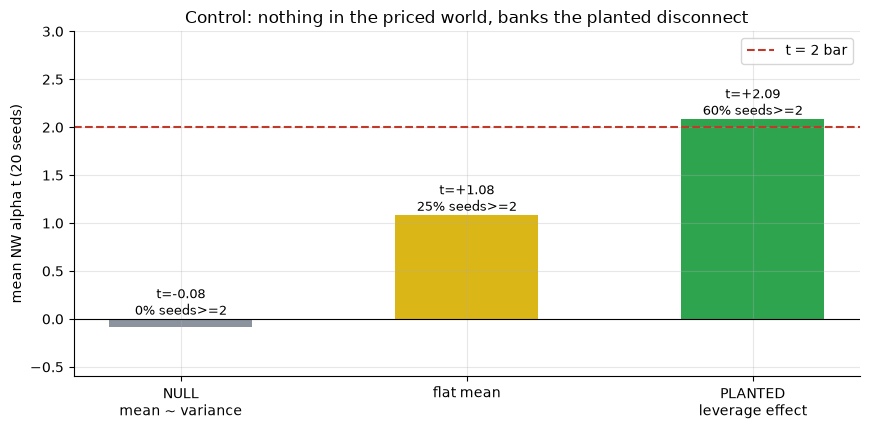

NULL mean ~ variance         mean t -0.08 (sd 1.24)  alpha -0.10%/yr  share t>=2 0%
flat mean                    mean t +1.08 (sd 1.10)  alpha +2.44%/yr  share t>=2 25%
PLANTED leverage effect      mean t +2.09 (sd 0.98)  alpha +5.01%/yr  share t>=2 60%


In [6]:
res = [(lab, st.synthetic_check(disconnect=d, n_seeds=20)) for lab, d in
       [('NULL\nmean ~ variance', 0.0), ('flat mean', 1.0), ('PLANTED\nleverage effect', 2.0)]]
fig, ax = plt.subplots(figsize=(8.8, 4.4))
labs = [r[0] for r in res]; ts = [r[1]['mean_t'] for r in res]
ax.bar(labs, ts, color=[GREY, AMBER, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t = 2 bar'); ax.axhline(0, c='k', lw=.8)
for i, r in enumerate(res):
    ax.annotate(f"t={r[1]['mean_t']:+.2f}\n{r[1]['share_t_ge_2']*100:.0f}% seeds>=2",
                (i, max(r[1]['mean_t'], 0)), ha='center', va='bottom', fontsize=9)
ax.set_ylabel('mean NW alpha t (20 seeds)'); ax.set_ylim(-0.6, 3.0)
ax.set_title('Control: nothing in the priced world, banks the planted disconnect'); ax.legend()
plt.tight_layout(); plt.show()
for lab, s in res:
    print(f"{lab.replace(chr(10),' '):28s} mean t {s['mean_t']:+.2f} (sd {s['sd_t']:.2f})  "
          f"alpha {s['mean_alpha_ann_pct']:+.2f}%/yr  share t>=2 {s['share_t_ge_2']*100:.0f}%")

> 💡 In plain words: in a world where risky months pay proportionally more, the thermostat earns **nothing** (mean t = -0.08) — it cannot manufacture alpha from vol clustering alone. Plant the real-world disconnect (vol up, reward down) and it banks it (mean t = +2.09). The flat-mean middle row is also a **power lesson**: even in a true mild Moreira-Muir world, 30-year samples often can't certify (mean t ≈ 1.1) — context for the real tape's t = 2.00-at-the-wire. *(Machinery proof only — never cited in support of the stamps.)*

## 5 · The verdict

- **Signal `MIXED`** — SPY alpha **+2.87%/yr** at NW **t = 2.00** (the bar, exactly), QQQ **+5.49%/yr at t = 2.61**, placebo **p = 0.030**; but EFA **t = 0.84**, IWM **t = 0.72**, and cap-1.0 **t = 1.44**. Real on US mega-caps, unsupported elsewhere — the split-by-leg amber, exactly the contested ground of the post-2017 literature.
- **Tradability `FRAGILE`** — negligible turnover, unlimited capacity, retail-accessible vehicle; but net of 5 bps + 1% borrow spread the alpha decertifies (**+2.46%/yr, t = 1.72**) even though the net Sharpe (0.69) still beats buy-and-hold (0.61).
- **Dodges crashes? `MIXED`** — GFC **−31.0% vs −50.8%** and 2022 **−15.8% vs −20.2%** dodged; COVID 2020 **−18.2% vs −19.4%** not dodged (entered at the cap off a record-calm January). Insurance only against storms that announce themselves.

## 6 · Going further

- **The frequency knob.** Daily-vol targeting reacts inside the month and would have cut some of the 2020 drawdown — at ~10× the turnover; the cost trade-off deserves its own study.
- **Expected-vol vs realized-vol.** Swapping RV for an EWMA or a GARCH forecast changes little at the monthly horizon (they are 0.9+ correlated); swapping for *implied* vol connects to [130-vol-risk-premium](../../130-vol-risk-premium/).
- **Why the paper's numbers are bigger.** 1926–2015 includes the 1930s (vol clustering at its most extreme), no cap, and an ex-post variance-matching constant. Our capped, past-only, ETF-era version is what a practitioner could actually have run.

*The reproducible core is offline and deterministic; every number here is printed by [`examples/verify.py`](../examples/verify.py). Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*